# Memory Capacity and Navigation Efficiency

**Research Question:** What is the minimum memory capacity required for efficient spatial navigation?

**Approach:** Test 4 memory sizes (20, 50, 100, unlimited nodes) plus baselines

---

In [ ]:
import numpy as np
np.random.seed(57)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
from labyrinth import LabyrinthEnv
from Agent import QLearning_agent
from memory_hierarchy_agents import ReactiveAgent, MinimalMemoryAgent, FullMemoryAgent

✓ Modules loaded


## Helper Functions with Loop Detection

In [ ]:
def detect_loop(history, window=20):
    if len(history) < window:
        return False
    recent = history[-window:]
    return len(set(recent)) <= 3

def run_episode(agent, env, agent_type='reactive', max_steps=10000, seed=None):
    obs, info = env.reset(seed=seed)
    if hasattr(agent, 'reset'):
        agent.reset()
    
    state_history = []
    visited_nodes = set()
    done = False
    steps = 0
    stuck = False
    
    while not done and steps < max_steps:
        current_node = info['node']
        visited_nodes.add(current_node)
        state_history.append(current_node)
        
        if steps > 0 and steps % 20 == 0:
            if detect_loop(state_history):
                stuck = True
                break
        
        if agent_type in ['reactive', 'minimal']:
            action = agent.choose_action(obs, info['has_water'], info['at_dead_end'])
        else:
            action = agent.choose_action(obs)
        
        obs, reward, done, truncated, info = env.step(action)
        steps += 1
    
    return {
        'steps': steps,
        'completed': done,
        'stuck_in_loop': stuck,
        'hit_limit': (steps >= max_steps and not done),
        'visited_nodes': len(visited_nodes),
        'coverage': len(visited_nodes) / env.num_nodes
    }

def evaluate_agent(agent, env, agent_type='reactive', num_trials=50, max_steps=10000):
    results = []
    for trial in range(num_trials):
        result = run_episode(agent, env, agent_type, max_steps, seed=3000+trial)
        results.append(result)
    
    df = pd.DataFrame(results)
    summary = {
        'total_trials': num_trials,
        'completed': df['completed'].sum(),
        'stuck_in_loop': df['stuck_in_loop'].sum(),
        'completion_rate': df['completed'].mean(),
        'avg_steps': df['steps'].mean(),
        'avg_steps_completed': df[df['completed']]['steps'].mean() if df['completed'].sum() > 0 else None,
        'avg_coverage': df['coverage'].mean(),
        'avg_nodes': df['visited_nodes'].mean()
    }
    return summary, df

print('Helper functions defined')

✓ Helper functions defined


---

# PART 1: Baseline Comparison

Establish Level 0 (no memory) and Level 2 (full learning) as reference points.

In [134]:
env = LabyrinthEnv(k=2, depth=6)
print(f'Environment: k={env.k}, depth={env.depth}, nodes={env.num_nodes}')
print(f'Optimal path: 12 steps')

Environment: k=2, depth=6, nodes=127
Optimal path: 12 steps


In [135]:
print('Testing Level 0: Reactive Agent')
reactive_agent = ReactiveAgent(k_actions=env.k)
reactive_summary, _ = evaluate_agent(reactive_agent, env, 'reactive', num_trials=50)

print(f'\nResults:')
print(f'  Memory: {reactive_agent.memory_bits} bits')
print(f'  Completion: {reactive_summary["completion_rate"]:.0%} ({reactive_summary["completed"]}/50)')
print(f'  Avg steps: {reactive_summary["avg_steps"]:.0f}')
if reactive_summary['avg_steps_completed']:
    print(f'  Completed: {reactive_summary["avg_steps_completed"]:.0f} steps')
print(f'  Stuck: {reactive_summary["stuck_in_loop"]}/50')

Testing Level 0: Reactive Agent

Results:
  Memory: 224 bits
  Completion: 36% (18/50)
  Avg steps: 7626
  Completed: 3405 steps
  Stuck: 0/50


In [136]:
print('Training Level 2: Full Memory Agent')
full_agent = FullMemoryAgent(num_states=env.observation_space.n, num_actions=env.action_space.n)

training_steps = 0
consecutive_optimal = 0

for episode in range(1000):
    obs, info = env.reset()
    done = False
    episode_steps = 0
    
    while not done and episode_steps < 10000:
        action = full_agent.choose_action(obs)
        next_obs, reward, done, truncated, info = env.step(action)
        full_agent.learn(obs, action, reward, next_obs, done)
        obs = next_obs
        episode_steps += 1
        training_steps += 1
    
    if episode_steps == 12:
        consecutive_optimal += 1
        if consecutive_optimal >= 5:
            print(f'  Converged at episode {episode+1} ({training_steps:,} steps)')
            break
    else:
        consecutive_optimal = 0

full_agent.epsilon = 0.0
full_summary, _ = evaluate_agent(full_agent, env, 'qlearning', num_trials=50)

print(f'\nResults:')
print(f'  Memory: {full_agent.memory_bits} bits')
print(f'  Completion: {full_summary["completion_rate"]:.0%}')
print(f'  Avg steps: {full_summary["avg_steps"]:.0f}')

Training Level 2: Full Memory Agent
  Converged at episode 293 (39,697 steps)

Results:
  Memory: 24384 bits
  Completion: 100%
  Avg steps: 12


---

# PART 2: Memory Capacity Variants

Test 4 memory sizes to find minimum required capacity:
- Level 1a: 20 nodes
- Level 1b: 50 nodes  
- Level 1c: 100 nodes
- Level 1d: Unlimited

In [137]:
memory_variants = [
    {'name': 'Level 1a', 'max_nodes': 20, 'label': '20 nodes'},
    {'name': 'Level 1b', 'max_nodes': 50, 'label': '50 nodes'},
    {'name': 'Level 1c', 'max_nodes': 100, 'label': '100 nodes'},
    {'name': 'Level 1d', 'max_nodes': None, 'label': 'Unlimited'}
]

variant_results = []

print('='*70)
print('TESTING MEMORY CAPACITY VARIANTS')
print('='*70)

for i, variant in enumerate(memory_variants):
    print(f'\n[{i+1}/4] {variant["name"]}: {variant["label"]}')
    
    agent = MinimalMemoryAgent(k_actions=env.k, max_memory_nodes=variant['max_nodes'])
    agent.reset_spatial_memory()
    
    summary, df = evaluate_agent(agent, env, 'minimal', num_trials=50)
    
    print(f'  Memory: {agent.memory_bits:,} bits')
    print(f'  Completion: {summary["completion_rate"]:.0%} ({summary["completed"]}/50)')
    print(f'  Avg steps: {summary["avg_steps"]:.0f}')
    if summary['avg_steps_completed']:
        print(f'  Completed: {summary["avg_steps_completed"]:.0f} steps')
    print(f'  Stuck: {summary["stuck_in_loop"]}/50')
    print(f'  Coverage: {summary["avg_coverage"]:.1%}')
    
    variant_results.append({
        'variant': variant['name'],
        'label': variant['label'],
        'max_nodes': variant['max_nodes'] if variant['max_nodes'] else 127,
        'memory_bits': agent.memory_bits,
        'completion_rate': summary['completion_rate'],
        'avg_steps': summary['avg_steps'],
        'avg_steps_completed': summary['avg_steps_completed'],
        'stuck': summary['stuck_in_loop'],
        'coverage': summary['avg_coverage']
    })

print('\n' + '='*70)

TESTING MEMORY CAPACITY VARIANTS

[1/4] Level 1a: 20 nodes
  Memory: 864 bits
  Completion: 90% (45/50)
  Avg steps: 1772
  Completed: 1736 steps
  Stuck: 5/50
  Coverage: 76.2%

[2/4] Level 1b: 50 nodes
  Memory: 1,824 bits
  Completion: 72% (36/50)
  Avg steps: 1954
  Completed: 2170 steps
  Stuck: 14/50
  Coverage: 73.8%

[3/4] Level 1c: 100 nodes
  Memory: 3,424 bits
  Completion: 62% (31/50)
  Avg steps: 1873
  Completed: 2098 steps
  Stuck: 18/50
  Coverage: 69.3%

[4/4] Level 1d: Unlimited
  Memory: 4,288 bits
  Completion: 46% (23/50)
  Avg steps: 2037
  Completed: 2160 steps
  Stuck: 27/50
  Coverage: 66.1%



In [138]:
# Create comparison DataFrame
all_data = [{'Level': 'Level 0', 'Type': 'Reactive', 'Memory': reactive_agent.memory_bits, 
             'Completion': f"{reactive_summary['completion_rate']:.0%}", 
             'Steps': reactive_summary['avg_steps_completed'] if reactive_summary['avg_steps_completed'] else reactive_summary['avg_steps']}]

for v in variant_results:
    all_data.append({
        'Level': v['variant'],
        'Type': v['label'],
        'Memory': v['memory_bits'],
        'Completion': f"{v['completion_rate']:.0%}",
        'Steps': v['avg_steps_completed'] if v['avg_steps_completed'] else v['avg_steps']
    })

all_data.append({'Level': 'Level 2', 'Type': 'Full Memory', 'Memory': full_agent.memory_bits,
                 'Completion': f"{full_summary['completion_rate']:.0%}", 'Steps': full_summary['avg_steps']})

df_results = pd.DataFrame(all_data)
print('\n' + '='*70)
print('MEMORY CAPACITY ANALYSIS')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)


MEMORY CAPACITY ANALYSIS
   Level        Type  Memory Completion       Steps
 Level 0    Reactive     224        36% 3404.611111
Level 1a    20 nodes     864        90% 1735.866667
Level 1b    50 nodes    1824        72% 2170.444444
Level 1c   100 nodes    3424        62% 2097.741935
Level 1d   Unlimited    4288        46% 2159.565217
 Level 2 Full Memory   24384       100%   12.000000


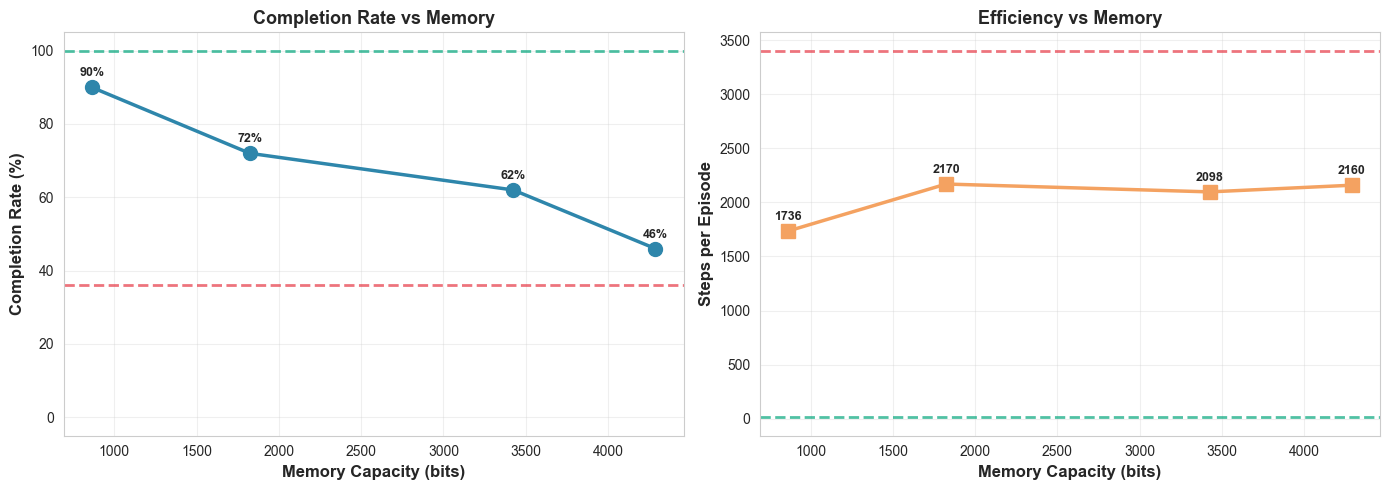

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

memory_sizes = [v['memory_bits'] for v in variant_results]
completions = [v['completion_rate'] * 100 for v in variant_results]
steps = [v['avg_steps_completed'] if v['avg_steps_completed'] else v['avg_steps'] for v in variant_results]

# Plot 1: Completion vs Memory
ax1 = axes[0]
ax1.plot(memory_sizes, completions, 'o-', linewidth=2.5, markersize=10, color='#2E86AB')
ax1.axhline(y=reactive_summary['completion_rate']*100, color='#E63946', linestyle='--', linewidth=2, alpha=0.7)
ax1.axhline(y=100, color='#06A77D', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Memory Capacity (bits)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Completion Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title('Completion Rate vs Memory', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(-5, 105)

for mem, comp in zip(memory_sizes, completions):
    ax1.annotate(f'{comp:.0f}%', (mem, comp), textcoords='offset points', 
                xytext=(0,8), ha='center', fontsize=9, fontweight='bold')

# Plot 2: Steps vs Memory
ax2 = axes[1]
ax2.plot(memory_sizes, steps, 's-', linewidth=2.5, markersize=10, color='#F4A261')
if reactive_summary['avg_steps_completed']:
    ax2.axhline(y=reactive_summary['avg_steps_completed'], color='#E63946', linestyle='--', linewidth=2, alpha=0.7)
ax2.axhline(y=full_summary['avg_steps'], color='#06A77D', linestyle='--', linewidth=2, alpha=0.7)
ax2.set_xlabel('Memory Capacity (bits)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Steps per Episode', fontsize=12, fontweight='bold')
ax2.set_title('Efficiency vs Memory', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

for mem, step in zip(memory_sizes, steps):
    ax2.annotate(f'{step:.0f}', (mem, step), textcoords='offset points', 
                xytext=(0,8), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

In [140]:
print('='*70)
print('KEY FINDINGS')
print('='*70)

best = max(variant_results, key=lambda x: x['completion_rate'])

print(f'\n1. MEMORY ENABLES NAVIGATION')
print(f'   Level 0: {reactive_summary["completion_rate"]:.0%}')
print(f'   Best ({best["label"]}): {best["completion_rate"]:.0%}')

for i in range(len(variant_results)-1):
    curr = variant_results[i]
    next_v = variant_results[i+1]
    mem_inc = next_v['memory_bits'] - curr['memory_bits']
    comp_inc = (next_v['completion_rate'] - curr['completion_rate']) * 100
    print(f'\n{curr["label"]} → {next_v["label"]}:')
    print(f'  Memory: +{mem_inc:,} bits')
    print(f'  Completion: {comp_inc:+.1f} pp')

print('\n' + '='*70)

KEY FINDINGS

1. MEMORY ENABLES NAVIGATION
   Level 0: 36%
   Best (20 nodes): 90%

20 nodes → 50 nodes:
  Memory: +960 bits
  Completion: -18.0 pp

50 nodes → 100 nodes:
  Memory: +1,600 bits
  Completion: -10.0 pp

100 nodes → Unlimited:
  Memory: +864 bits
  Completion: -16.0 pp



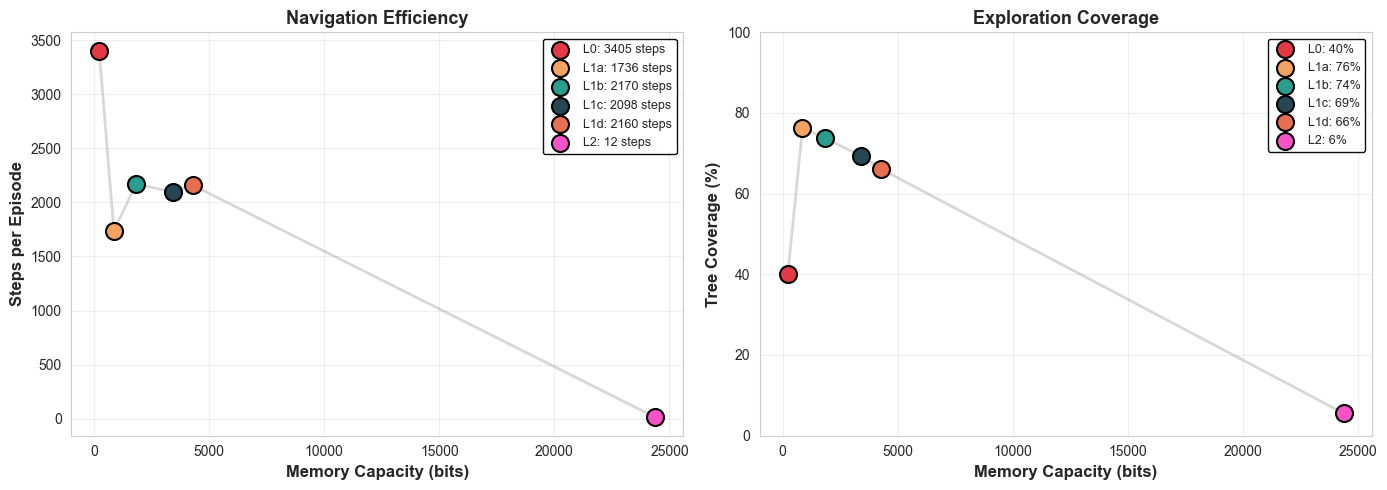

In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract data
memory_sizes = [reactive_agent.memory_bits] + [v['memory_bits'] for v in variant_results] + [full_agent.memory_bits]
completions = [reactive_summary['completion_rate']*100] + [v['completion_rate']*100 for v in variant_results] + [full_summary['completion_rate']*100]
steps = [reactive_summary['avg_steps_completed'] if reactive_summary['avg_steps_completed'] else reactive_summary['avg_steps']] + \
        [v['avg_steps_completed'] if v['avg_steps_completed'] else v['avg_steps'] for v in variant_results] + \
        [full_summary['avg_steps']]
labels = ['L0', 'L1a', 'L1b', 'L1c', 'L1d', 'L2']
colors = ['#E63946', '#F4A261', '#2A9D8F', '#264653', '#E76F51', "#F753C8"]

# Panel A: Steps per Episode vs Memory (WITH L2)
ax1 = axes[0]
ax1.plot(memory_sizes, steps, '-', linewidth=2, color='gray', alpha=0.3, zorder=1)

# Find optimal point (among L0-L1d, not L2)
optimal_idx = steps[:-1].index(min(steps[:-1]))

for i, (mem, step, label, color) in enumerate(zip(memory_sizes, steps, labels, colors)):
    # Highlight optimal among L0-L1d
    if i == optimal_idx:
        marker_size = 150
        edge_color = 'black'
        edge_width = 1.5
    else:
        marker_size = 150
        edge_color = 'black'
        edge_width = 1.5
    
    ax1.scatter(mem, step, s=marker_size, color=color, zorder=3, 
               edgecolors=edge_color, linewidth=edge_width, label=f'{label}: {step:.0f} steps')

ax1.set_xlabel('Memory Capacity (bits)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Steps per Episode', fontsize=12, fontweight='bold')
ax1.set_title('Navigation Efficiency', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.95, edgecolor='black')

# Panel B: Coverage (WITH L2)
ax2 = axes[1]
coverage = [reactive_summary['avg_coverage']*100] + [v['coverage']*100 for v in variant_results] + [full_summary['avg_coverage']*100]
ax2.plot(memory_sizes, coverage, '-', linewidth=2, color='gray', alpha=0.3, zorder=1)

for i, (mem, cov, label, color) in enumerate(zip(memory_sizes, coverage, labels, colors)):
    ax2.scatter(mem, cov, s=150, color=color, zorder=3, edgecolors='black', linewidth=1.5, label=f'{label}: {cov:.0f}%')

ax2.set_xlabel('Memory Capacity (bits)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Tree Coverage (%)', fontsize=12, fontweight='bold')
ax2.set_title('Exploration Coverage', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.95, edgecolor='black')

plt.tight_layout()
plt.show()

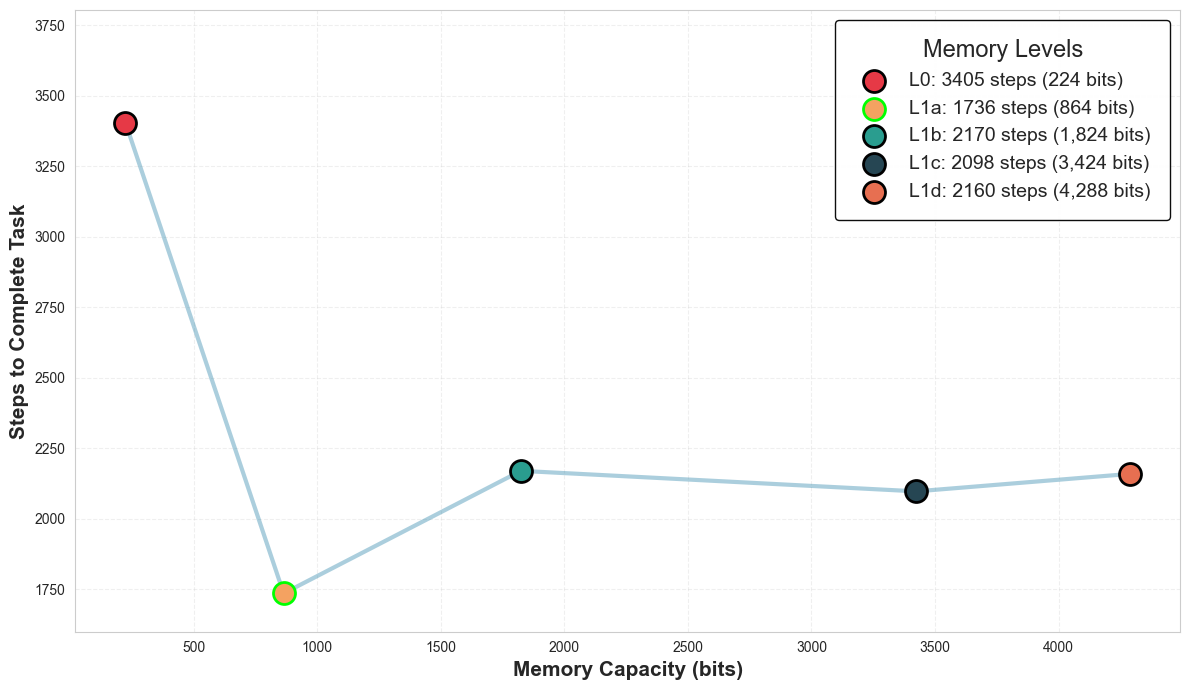


Key Finding: L1a is optimal
  Memory: 864 bits
  Steps: 1736
  vs Unlimited (L1d): 2160 steps
  → 24.4% faster with LIMITED memory


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

# Data for Levels 0-1d only
memory_subset = memory_sizes[:-1]
steps_subset = steps[:-1]
labels_subset = labels[:-1]

# Plot the U-curve line
ax.plot(memory_subset, steps_subset, '-', linewidth=3, color='#2E86AB', alpha=0.4, zorder=1)

# Find optimal
optimal_idx = steps_subset.index(min(steps_subset))

# Plot each point
for i, (mem, step, label, color) in enumerate(zip(memory_subset, steps_subset, labels_subset, colors[:-1])):
    if i == optimal_idx:
        size = 250
        edge_color = 'lime'
        edge_width = 2
        marker = 'o'
    else:
        size = 250
        edge_color = 'black'
        edge_width = 2
        marker = 'o'
    
    ax.scatter(mem, step, s=size, color=color, zorder=3, 
              edgecolors=edge_color, linewidth=edge_width, marker=marker,
              label=f'{label}: {step:.0f} steps ({mem:,} bits)')

ax.set_xlabel('Memory Capacity (bits)', fontsize=15, fontweight='bold')
ax.set_ylabel('Steps to Complete Task', fontsize=15, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(1600, max(steps_subset) + 400)

# Legend at bottom right
ax.legend(loc='upper right', fontsize=14, framealpha=0.95, edgecolor='black', 
         title='Memory Levels', title_fontsize=17, borderpad=1)

plt.tight_layout()
plt.show()


print(f'\nKey Finding: {labels_subset[optimal_idx]} is optimal')
print(f'  Memory: {memory_subset[optimal_idx]:,} bits')
print(f'  Steps: {steps_subset[optimal_idx]:.0f}')
print(f'  vs Unlimited ({labels_subset[-1]}): {steps_subset[-1]:.0f} steps')
print(f'  → {((steps_subset[-1] - steps_subset[optimal_idx])/steps_subset[optimal_idx]*100):.1f}% faster with LIMITED memory')

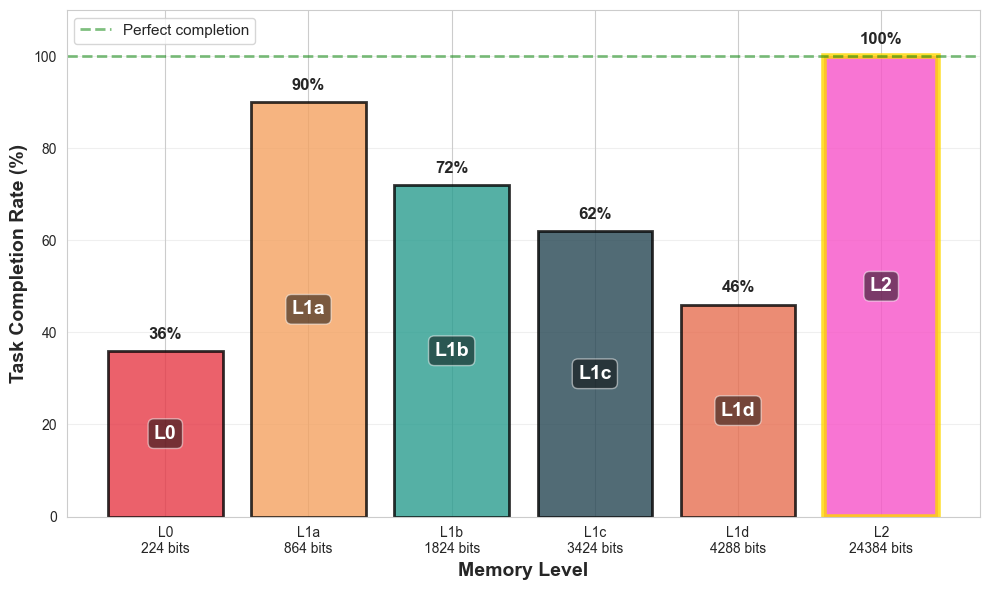

In [147]:
fig, ax = plt.subplots(figsize=(10, 6))

# Bar chart data
x_pos = np.arange(len(labels))
completion_data = completions

# Create bars with different colors
bars = ax.bar(x_pos, completion_data, color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add value labels on bars
for i, (bar, comp, label) in enumerate(zip(bars, completion_data, labels)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
           f'{comp:.0f}%',
           ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Add level label inside bar
    ax.text(bar.get_x() + bar.get_width()/2., height/2,
           label,
           ha='center', va='center', fontsize=14, fontweight='bold', color='white',
           bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.5))

# Highlight 100% bars
for i, comp in enumerate(completion_data):
    if comp == 100:
        bars[i].set_edgecolor('gold')
        bars[i].set_linewidth(4)

# Add horizontal line at 100%
ax.axhline(y=100, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Perfect completion')
ax.set_xlabel('Memory Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Task Completion Rate (%)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{l}\n{m} bits' for l, m in zip(labels, memory_sizes)], fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()